--- Dataset Loaded Successfully ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40 



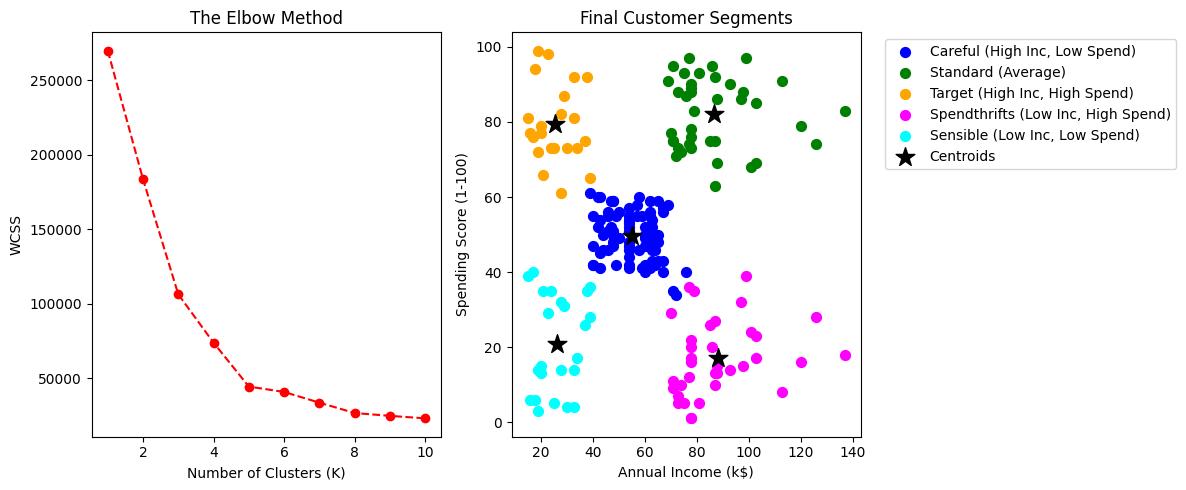

In [1]:
# 1. Necessary Libraries Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# 2. Load Dataset from Kaggle Path
try:
    df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
    print("--- Dataset Loaded Successfully ---")
    print(df.head(), "\n")
except FileNotFoundError:
    # Alternative common kaggle path if the above slightly differs
    df = pd.read_csv('../input/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

# 3. Feature Selection (Annual Income and Spending Score)
X = df.iloc[:, [3, 4]].values

# 4. Finding Optimal Clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='red')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

# 5. Training K-Means Model with Optimal K (K=5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# 6. Visualizing the 5 Distinct Customer Segments
plt.subplot(1, 2, 2)
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 50, c = 'blue', label = 'Careful (High Inc, Low Spend)')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 50, c = 'green', label = 'Standard (Average)')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 50, c = 'orange', label = 'Target (High Inc, High Spend)')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 50, c = 'magenta', label = 'Spendthrifts (Low Inc, High Spend)')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 50, c = 'cyan', label = 'Sensible (Low Inc, Low Spend)')

# Plotting Centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 200, c = 'black', label = 'Centroids', marker='*')

plt.title('Final Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Legend outside for clarity

plt.tight_layout()
plt.show()


# Advanced

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values Count:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:
                         count    mean        std   min    25%    50%     75%  \
CustomerID              200.0  100.50  57.879185   1.0  50.75  100.5  150.25   
Age                     200.0   38.85  13.969007  18.0  28.75   36.0   49.00   
Annual Income (k$)  

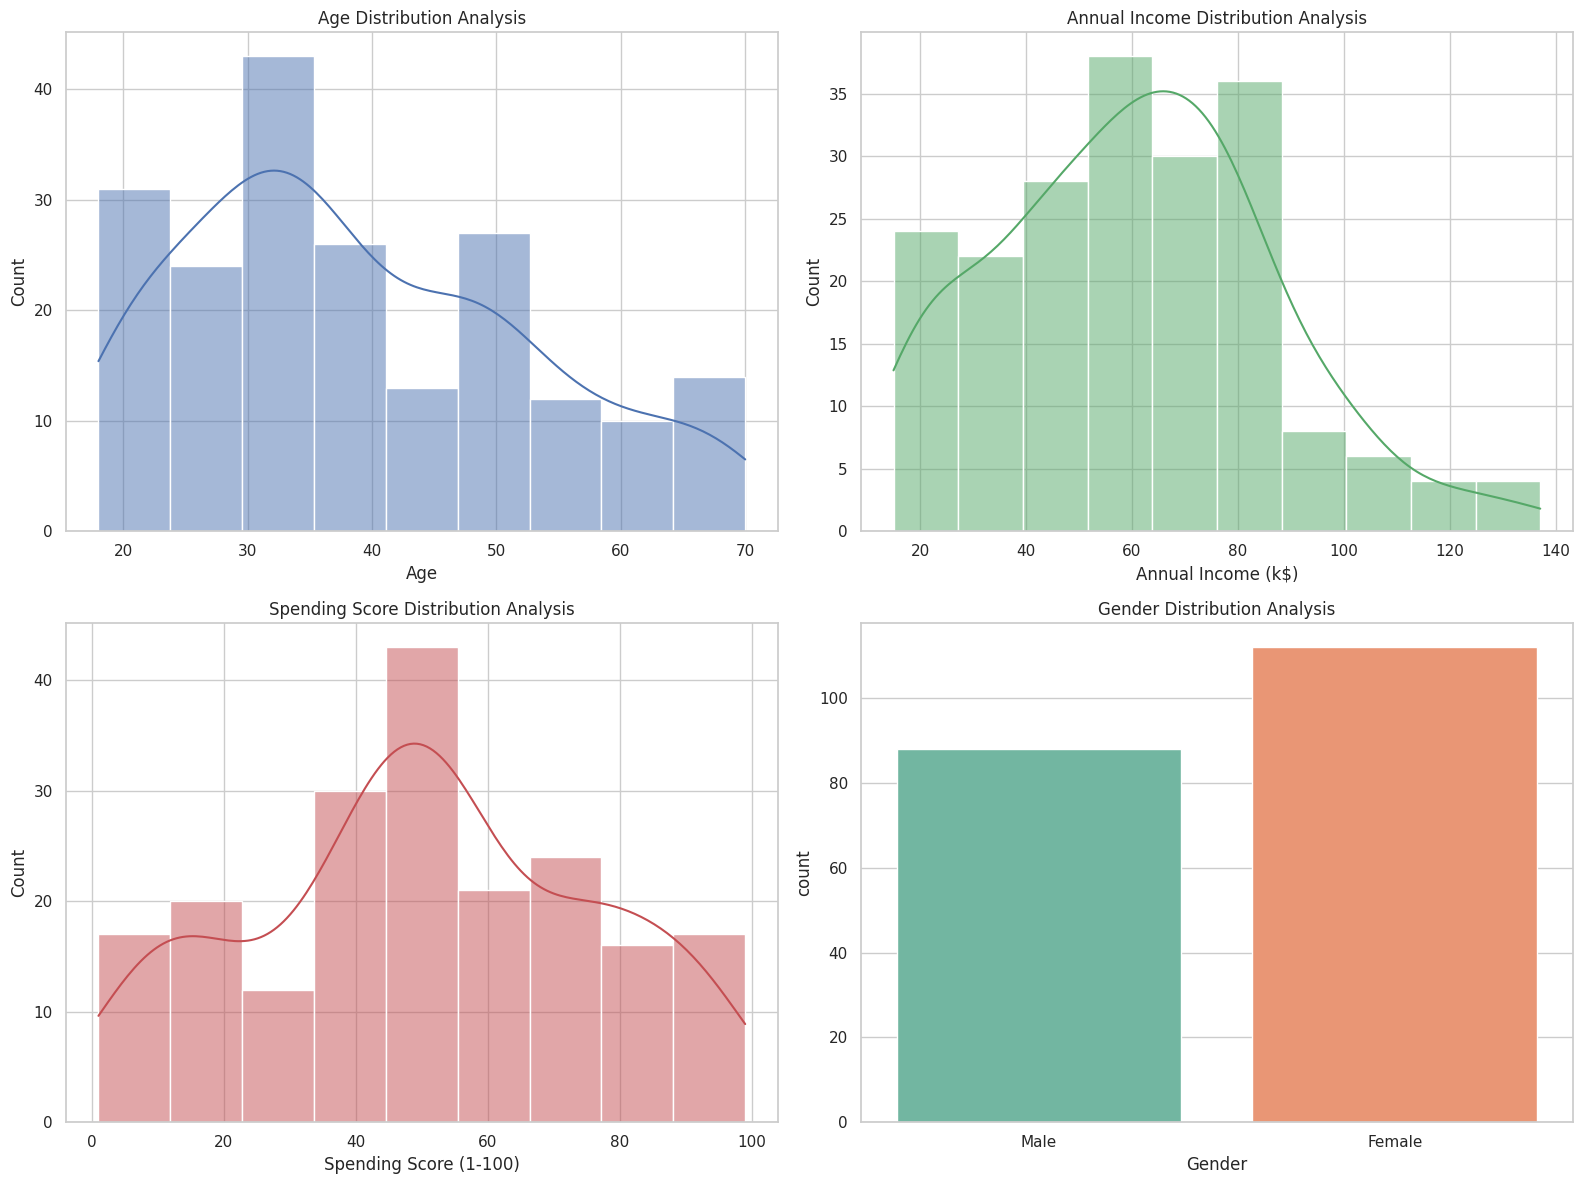


Generating Feature Pairplot Grid...


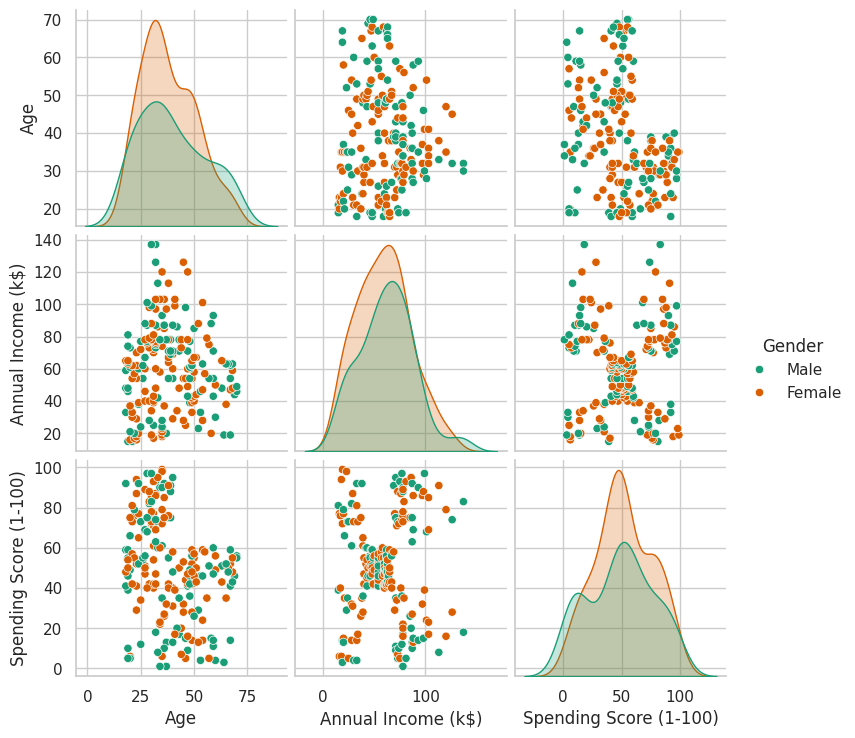

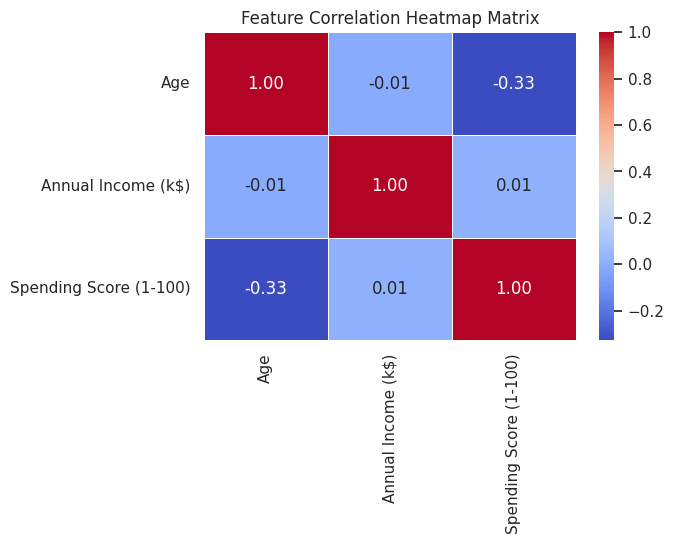

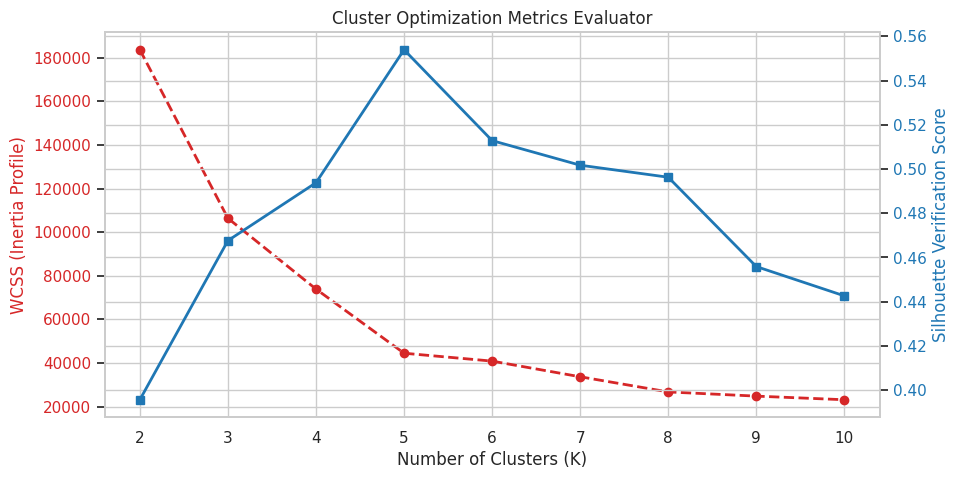

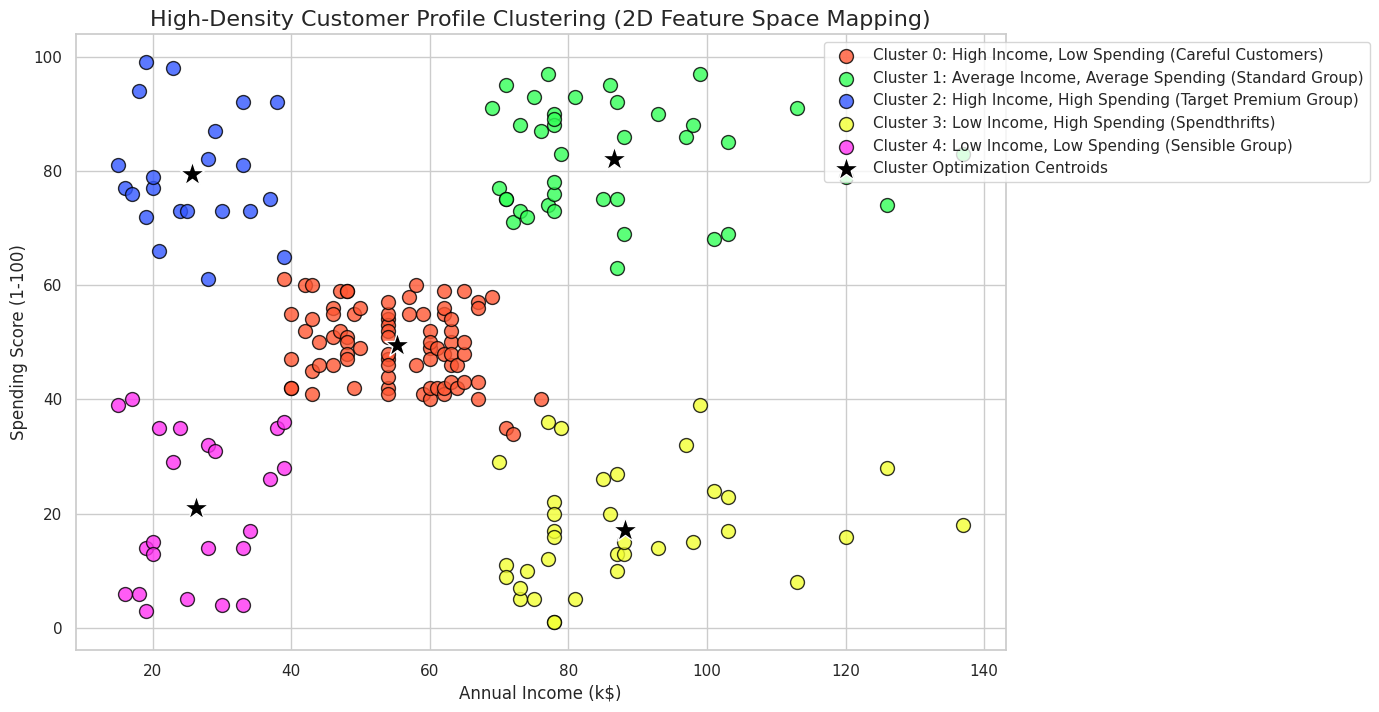


Generating Interactive 3D Scatter Workspace...


In [3]:
# ==============================================================================
# 1. SETUP AND LIBRARY IMPORTS
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic styling for matplotlib/seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12

# ==============================================================================
# 2. DATA LOADING & QUALITY CHECK
# ==============================================================================
try:
    df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
except FileNotFoundError:
    df = pd.read_csv('../input/customer-segmentation-tutorial-in-python/Mall_Customers.csv')

print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(df.info())
print("\nMissing Values Count:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe().T)

# ==============================================================================
# 3. DETAILED EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Distribution of Numeric Numerical Columns
for i, col in enumerate(['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.histplot(df[col], kde=True, ax=axes[0, 0] if i==0 else (axes[0, 1] if i==1 else axes[1, 0]), 
                 color=['#4C72B0', '#55A868', '#C44E52'][i])
axes[0, 0].set_title('Age Distribution Analysis')
axes[0, 1].set_title('Annual Income Distribution Analysis')
axes[1, 0].set_title('Spending Score Distribution Analysis')

# Subplot 2: Gender Proportion Count
sns.countplot(x='Gender', data=df, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Gender Distribution Analysis')

plt.tight_layout()
plt.show()

# Pairplot to uncover bivariate distributions across features
print("\nGenerating Feature Pairplot Grid...")
sns.pairplot(df.drop('CustomerID', axis=1), hue='Gender', palette='Dark2', height=2.5)
plt.show()

# Feature Correlation Matrix Visualized
plt.figure(figsize=(6, 4))
numeric_df = df.drop(['CustomerID', 'Gender'], axis=1)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap Matrix')
plt.show()

# ==============================================================================
# 4. FEATURE SELECTION AND MODEL OPTIMIZATION
# ==============================================================================
# Isolate primary matrices for clustering configuration
X_2d = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
X_3d = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

wcss = []
silhouette_scores = []
cluster_range = range(2, 11)

# Compute tuning parameters iteratively
for i in cluster_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_2d)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_2d, kmeans.labels_))

# Plot Optimization Curves (Elbow and Silhouette Score Profile)
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS (Inertia Profile)', color=color)
ax1.plot(cluster_range, wcss, marker='o', color=color, linestyle='--', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Cluster Optimization Metrics Evaluator')

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Verification Score', color=color)
ax2.plot(cluster_range, silhouette_scores, marker='s', color=color, linestyle='-', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.show()

# ==============================================================================
# 5. MODEL EXECUTION AND 2D VECTOR VISUALIZATION
# ==============================================================================
# Optimal cluster count verified at K=5 via metric evaluation step
optimal_k = 5
kmeans_2d = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
labels_2d = kmeans_2d.fit_predict(X_2d)
df['Cluster_2D'] = labels_2d

# Build 2D Cluster Segment Visualizer Map
plt.figure(figsize=(12, 8))
colors = ['#FF5733', '#33FF57', '#3357FF', '#F3FF33', '#FF33F3']
cluster_labels = [
    'Cluster 0: High Income, Low Spending (Careful Customers)',
    'Cluster 1: Average Income, Average Spending (Standard Group)',
    'Cluster 2: High Income, High Spending (Target Premium Group)',
    'Cluster 3: Low Income, High Spending (Spendthrifts)',
    'Cluster 4: Low Income, Low Spending (Sensible Group)'
]

for i in range(optimal_k):
    plt.scatter(X_2d[labels_2d == i, 0], X_2d[labels_2d == i, 1], 
                s=100, c=colors[i], label=cluster_labels[i], edgecolors='black', alpha=0.8)

# Overlay model cluster centroids
plt.scatter(kmeans_2d.cluster_centers_[:, 0], kmeans_2d.cluster_centers_[:, 1], 
            s=350, c='black', label='Cluster Optimization Centroids', marker='*', edgecolors='white')

plt.title('High-Density Customer Profile Clustering (2D Feature Space Mapping)', fontsize=16)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
plt.show()

# ==============================================================================
# 6. INTERACTIVE 3D COMPREHENSIVE SEGMENTATION (AGE INCLUDED)
# ==============================================================================
print("\nGenerating Interactive 3D Scatter Workspace...")
# Execute separate 3-dimensional evaluation algorithm across all main variables
kmeans_3d = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
labels_3d = kmeans_3d.fit_predict(X_3d)
df['Cluster_3D'] = labels_3d

# Plotly Interactive Render Call
fig_3d = px.scatter_3d(
    df, 
    x='Age', 
    y='Annual Income (k$)', 
    z='Spending Score (1-100)',
    color='Cluster_3D', 
    opacity=0.8,
    title="Comprehensive 3D Structural Customer Cohort Topology",
    labels={'Cluster_3D': 'Assigned Cluster ID'},
    color_continuous_scale=px.colors.sequential.Viridis
)
fig_3d.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_3d.show()
